# Prognose for akutmodtagelsens besøgsvolumen med eksponentiel udglatning (PROC ESM)


## Sammenfatning for ledelsen

Et mellemstort hospitalssystem har brug for en prognose et år frem for det månedlige besøgsvolumen på akutmodtagelsen (ED) for at planlægge sygeplejerskebemanding og sengekapacitet forud for vinterens luftvejsbølge. Denne notebook opbygger en syntetisk fireårig månedlig ED-tælling (48 måneder, jan. 2021 - dec. 2024) og tilpasser en Winters multiplikativ sæsonmodel med **PROC ESM** for at frembringe en 12-måneders prognose med 95% prædiktionsintervaller.

Den tilpassede model indfanger serien godt: in-sample **RMSE er cirka 320 besøg** og **MAPE er 4.16%**, så den typiske månedlige fejl er under 5% af volumen. Prognosen fremskriver den velkendte sæsonform ind i 2025 - en top i december-februar nær **7,300-7,800 besøg/måned** og en bund i sensommeren nær **5,800-5,900** - med prædiktionsbånd, der bliver bredere, efterhånden som horisonten strækker sig. Disse tal, og de udglatningsvægte, der ligger bag dem, aflæses direkte fra procedurens output-datasæt nedenfor.


## Datakilder

| Datasæt | Rækker | Granularitet | Nøglevariabler | Beskrivelse |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Én række pr. kalendermåned, jan. 2021 - dec. 2024 | `month` (månedlig SAS-dato), `ed_visits` (heltalligt månedligt ED-besøgstal) | Syntetisk månedligt besøgsvolumen på akutmodtagelsen for et mellemstort hospitalssystem. Genereret med en opadgående væksttrend (~3% årligt), en multiplikativ sæsoncyklus med top i vinterens luftvejssæson (dec.-feb.) og bund i sensommeren, plus log-normal støj, så sæsonamplituden skalerer med det stigende niveau. |


# Prognose for akutmodtagelsens besøgsvolumen med PROC ESM

Kapacitetsplanlæggere har brug for at vide, hvor mange ED-besøg de kan forvente hver måned, så de kan planlægge sygeplejersker, holde flex-senge klar og klargøre luftvejsforsyninger inden vinterbølgen. ED-volumen er en lærebogseksempel på en sæsonbestemt tidsserie: den vokser langsomt år for år, topper i december-februar-luftvejssæsonen og ebber ud i sensommeren, og størrelsen af sæsonudsvinget vokser, i takt med at basisvolumen vokser. Netop den multiplikative sæsonstruktur er, hvad Winters multiplikative metode i **PROC ESM** er designet til at indfange.

I denne notebook vil vi:

1. Generere en realistisk fireårig månedlig ED-tælling med trend, multiplikativ sæsonbestemthed og støj.
2. Visualisere serien for at bekræfte dens multiplikative sæsonstruktur.
3. Tilpasse en Winters multiplikativ model med PROC ESM og aflæse dens udglatningsvægte og tilpasningsstatistikker fra output-datasættene.
4. Frembringe en prognose 12 måneder frem med 95% prædiktionsintervaller og fortolke de operationelle konsekvenser.


## Trin 1 - Generér den syntetiske månedlige ED-tælling

Vi bygger 48 månedlige observationer fra januar 2021 til december 2024. Hver måneds forventede volumen er et basisniveau, der vokser cirka 3% om året, ganget med et sæsonindeks (højest midt om vinteren, lavest i sensommeren) og derefter forstyrret af log-normal støj, så den tilfældige variation skalerer med niveauet. `intnx` rykker den måneds-justerede dato én periode frem pr. række, og `streaminit` gør trækningen reproducerbar.


In [1]:
data ed_census;
    CALL streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    TABEL seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    format month yymmn6.;
    GØR i = 1 TIL 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        UDDATA;
    SLUT;
    BEHOLD month ed_visits;
KØR;

PROCEDURE UDSKRIV data=ed_census(obs=14) noobs MÆRKAT;
    MÆRKAT month = "Måned" ed_visits = "Akutbesøg";
    TITEL "De første 14 måneder af syntetisk akutbesøgsvolumen";
KØR;


                                  De første 14 måneder af syntetisk akutbesøgsvolumen                                   

 Måned   Akutbesøg
202101        7103
202102        6835
202103        6668
202104        5611
202105        5816
202106        5383
202107        5586
202108        5283
202109        5161
202110        6109
202111        6451
202112        6730
202201        6847
202202        7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


De første måneder bekræfter designet: volumen åbner nær 7,100 i januar 2021-toppen, falder gennem forår og sommer til sin bund i august-september og klatrer derefter tilbage ind i den næste vinter. I januar 2022 er toppen kravlet op til cirka 6,800-7,200, hvilket afspejler den ~3% årlige vækst lagt oven på sæsoncyklussen.


## Trin 2 - Visualisér serien

Inden modellering plottes den rå serie for at bekræfte den struktur, vi forventer: en blid opadgående trend med en gentagen årlig top hver vinter, hvis amplitude udvides over tid. Et udvidende sæsonudsving er signaturen på en *multiplikativ* sæsonproces og fortæller os, hvilken ESM-model vi skal vælge.


                                  De første 14 måneder af syntetisk akutbesøgsvolumen                                   




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


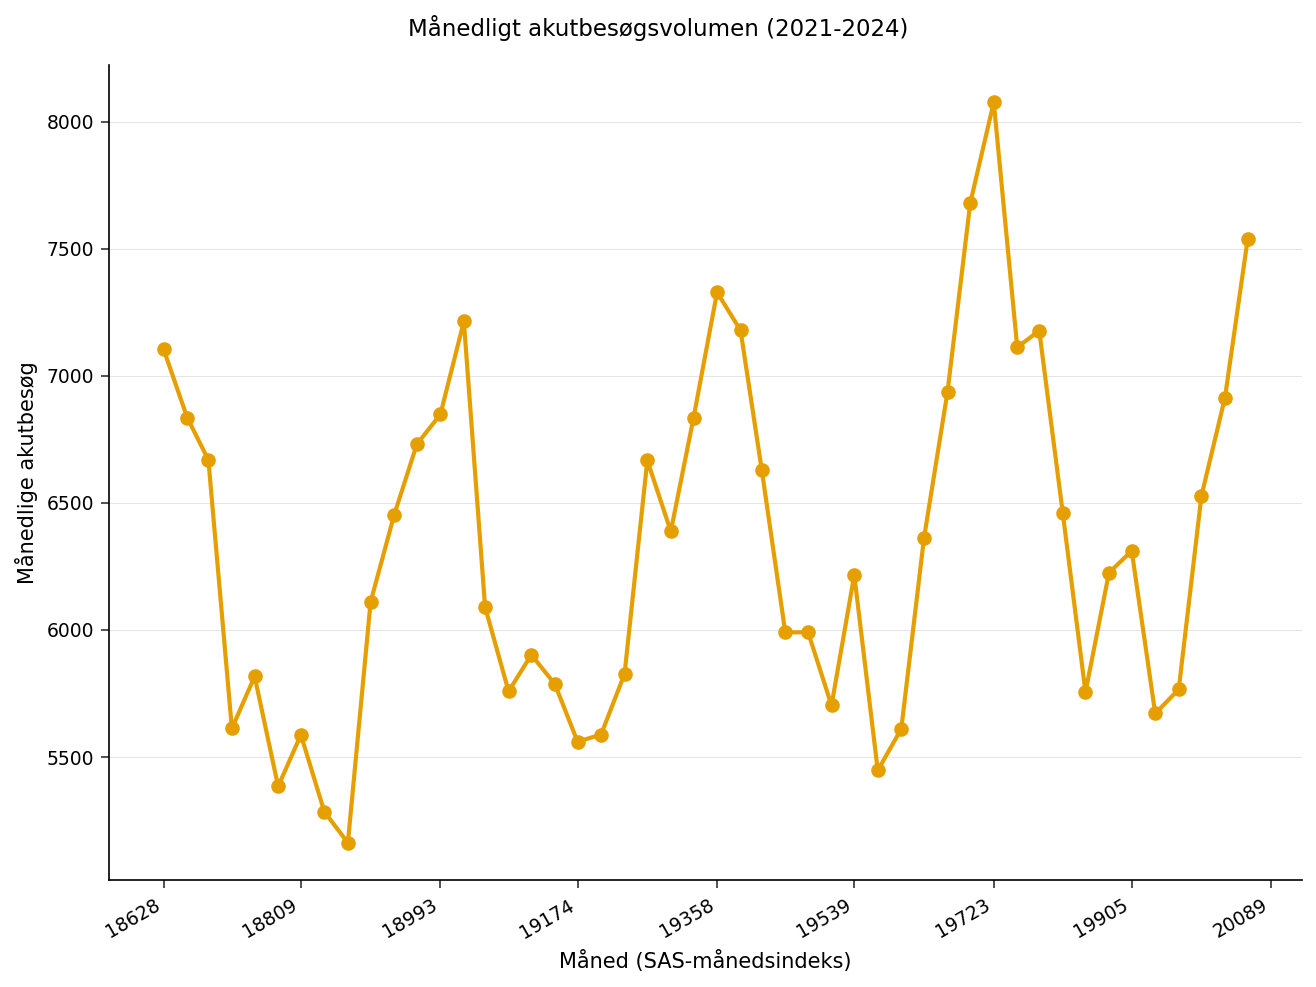

In [2]:
PROCEDURE SGPLOT data=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS MÆRKAT="Måned (SAS-månedsindeks)";
    YAXIS MÆRKAT="Månedlige akutbesøg" grid;
    TITEL "Månedligt akutbesøgsvolumen (2021-2024)";
KØR;


Plottet viser fire rene årlige cyklusser. Hver vintertop ligger en anelse højere end den forrige og klatrer fra omkring 7,100 i 2021 til cirka 8,100 ved 2024-toppen, mens sommerbundene stiger mere beskedent - sæsonudsvinget vokser med niveauet. Den udvidende amplitude er kendetegnet ved multiplikativ sæsonbestemthed og retfærdiggør `MODEL=WINTERS` (Winters multiplikativ) i det næste trin.


## Trin 3 - Tilpas den Winters multiplikative model

Vi tilpasser Winters multiplikativ sæsonudglatning på den fulde 48-måneders historik. `ID`-sætningen erklærer `month` som tidsindekset med et `MONTH`-interval, og `FORECAST`-sætningen anmoder om `MODEL=WINTERS` med `LEAD=12` for at fremskrive et år frem. Vi opsamler tre output-datasæt:

- `OUT=` - den historiske serie med prognosen tilføjet (én `ed_visits`-kolonne), med tids-id'et udvidet over prognosehorisonten - ideel til plotning.
- `OUTFOR=` - de periodevise prognosekomponenter: punktprognose (`PREDICT`) og de nedre/øvre prædiktionsgrænser.
- `OUTSUM=` - modellens tilpasningsstatistikker (RMSE, MAE, MAPE, AIC) og udglatningsvægte, i en enkelt opsummeringsrække.

`ALPHA=0.05` giver 95% prædiktionsgrænser, passende for risikomarginer i kapacitetsplanlægning. `PRINT=(STATISTICS)` gengiver tilpasningsstatistikkerne og udglatningsvægtene til listingen.


In [3]:
PROCEDURE esm data=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        print=(statistics);
    id month interval=month;
    forecast ed_visits / MODEL=winters ALPHA=0.05;
KØR;

PROCEDURE UDSKRIV data=esm_summary noobs MÆRKAT;
    MÆRKAT rmse="RMSE" mae="MAE" mape="MAPE"
          ALPHA="Niveau (alfa)" beta="Trend (beta)" gamma="Sæson (gamma)";
    VARIABEL rmse mae mape ALPHA beta gamma;
    TITEL "Winters-tilpasningsstatistik og udjævningsvægte";
KØR;


                                  De første 14 måneder af syntetisk akutbesøgsvolumen                                   


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                    Winters-tilpasningsstatistik og udjævningsvægte                                     

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


`OUTSUM=`-rækken og de udskrevne statistikker stemmer overens: den Winters multiplikative tilpasning opnår en in-sample **RMSE på 320.4 besøg**, **MAE på 264.4** og **MAPE på 4.16%** - en typisk månedlig fejl et godt stykke under 5% af volumen, hvilket er komfortabelt nøjagtigt til bemandingsplanlægning. Udglatningsvægtene er **alpha = 0.30** (niveau), **beta = 0.10** (trend) og **gamma = 0.10** (sæson). Den moderate niveauvægt lader basislinjen drive opad med væksten i patientpopulationen, mens de små trend- og sæsonvægte afspejler, at vækstraten og vinterbølgens form er stabile fra år til år og ikke bør overreageres på fra måned til måned.

> Bemærk: dette er *in-sample*-tilpasningsstatistikker beregnet over estimeringsstikprøven, ikke en out-of-sample-holdout. De kvantificerer, hvor tæt modellen følger den historik, den blev tilpasset på.


## Trin 4 - Saml og tabulér 12-måneders-prognosen

`OUTFOR=`-datasættet rummer punktprognosen og prædiktionsgrænserne for hver periode, mens `OUT=`-datasættet bærer tids-id'et udvidet rent over prognosehorisonten. Vi justerer de to efter observationsrækkefølge for at knytte prognosedatoerne til prædiktionsgrænserne og beholder derefter kun de 12 prognosemåneder. Dette er de tal, et bemandingsudvalg ville handle på.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
data out_idx;
    SÆT ed_with_forecast;
    row = _n_;
    OMDØB month = fdate ed_visits = series_value;
KØR;

data for_idx;
    SÆT esm_forecast;
    row = _n_;
    OMDØB ed_visits = observed;
    BEHOLD row observed predict LOWER UPPER;
KØR;

data forecast_path;
    SAMMENFLET out_idx for_idx;
    EFTER row;
    format fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
KØR;

data forecast_horizon;
    SÆT forecast_path;
    HVOR observed = .;   /* forecast months only (no observed value) */
    BEHOLD fdate predict LOWER UPPER;
KØR;

PROCEDURE UDSKRIV data=forecast_horizon noobs MÆRKAT;
    MÆRKAT fdate   = "Måned"
          predict = "Prognosebesøg"
          LOWER   = "95% nedre"
          UPPER   = "95% øvre";
    TITEL "12-måneders akutbesøgsprognose med 95% prognosegrænser";
KØR;


                                 12-måneders akutbesøgsprognose med 95% prognosegrænser                                 

 Måned   Prognosebesøg  95% nedre   95% øvre
202501           7,822      7,194      8,450
202502           7,539      6,651      8,427
202503           7,292      6,204      8,380
202504           6,263      5,007      7,519
202505           6,397      4,992      7,801
202506           6,039      4,501      7,578
202507           6,236      4,574      7,897
202508           5,867      4,091      7,644
202509           5,802      3,918      7,686
202510           6,804      4,818      8,790
202511           7,173      5,090      9,256
202512           7,567      5,391      9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


Prognosen fører sæsonsignaturen frem i 2025. Modellen fremskriver januar 2025-toppen til cirka **7,822 besøg** (95%-interval 7,194-8,450), aftager gennem foråret, bunder ud i sensommertruget nær **5,802** i september (interval 3,918-7,686) og genopbygges til en decembertop på omtrent **7,567** (interval 5,391-9,742). Prædiktionsbåndet udvides støt med horisonten - næste måneds interval spænder cirka +/-630 besøg, mens næste decembers spænder mere end +/-2,000 - en direkte påmindelse om, at kortsigtede planer er langt fastere end dem ved årets slutning.


## Trin 5 - Plot historik plus prognose

Endelig overlejrer vi prognosen på den observerede historik, så planlæggere kan se den fremskrevne vintertop og det udvidende usikkerhedsbånd, efterhånden som horisonten strækker sig. Vi opdeler den justerede `forecast_path`-serie i den **observerede** historik (fuldt optrukket) og den **12-måneders prognose** (stiplet), så overgangen er tydelig, og tegner 95% prædiktionsbåndet nedenunder. X-aksen er det månedlige SAS-datoindeks, der løber fra venstre mod højre fra jan. 2021 til dec. 2025.


                                 12-måneders akutbesøgsprognose med 95% prognosegrænser                                 




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


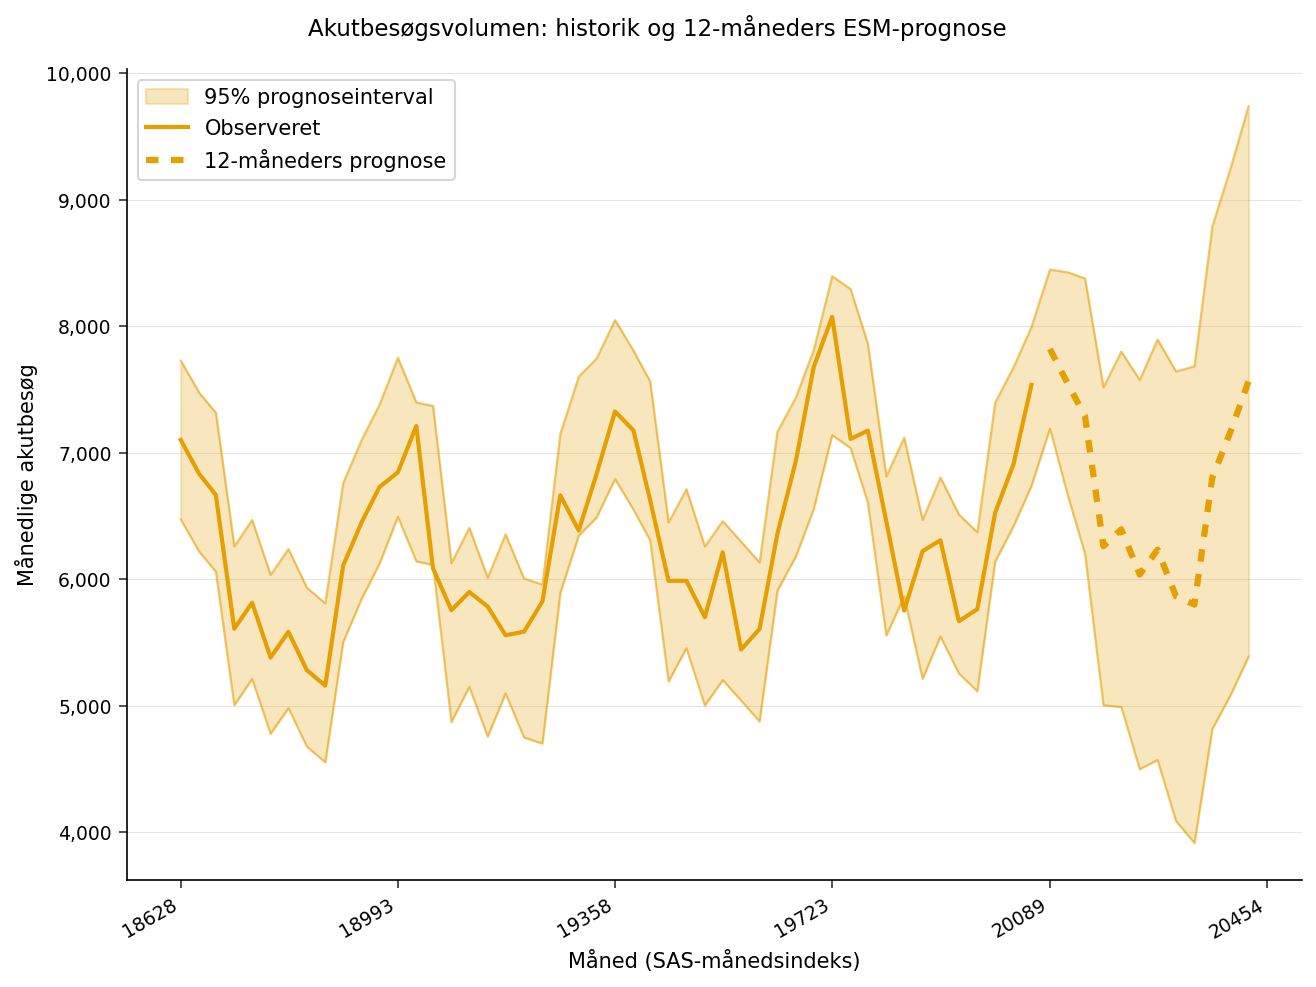

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
data forecast_plot;
    SÆT forecast_path;
    HVIS observed = . SÅ fc_only = predict;   /* future months only */
    ELLERS fc_only = .;
KØR;

PROCEDURE SGPLOT data=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel="95% prognoseinterval" TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel="Observeret";
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel="12-måneders prognose";
    XAXIS MÆRKAT="Måned (SAS-månedsindeks)";
    YAXIS MÆRKAT="Månedlige akutbesøg" grid;
    TITEL "Akutbesøgsvolumen: historik og 12-måneders ESM-prognose";
KØR;


## Fortolkning af resultaterne

Den Winters multiplikative model dekomponerer ED-volumen i et langsomt stigende **niveau**, en næsten flad **trend** og et stabilt **sæsonmønster**. Udglatningsvægtene aflæst fra `OUTSUM=` fortæller historien: en moderat niveauvægt (alpha = 0.30) lader basislinjen drive opad med væksten i patientpopulationen, mens små trend- og sæsonvægte (beta = gamma = 0.10) afspejler, at vækstraten og vinterbølgens form er meget stabile fra år til år og ikke bør overreageres på fra måned til måned.

**Tilpasningsstatistikkerne** bekræfter, at modellen følger historikken godt: en RMSE på cirka 320 besøg og en MAPE på 4.16% betyder, at den typiske månedlige fejl er under 5% af volumen. Operationelt kvantificerer **prognosetabellen og båndplottet** den december-februar-top, ED'en bør bemande mod - omtrent 7,300-7,800 besøg i vintermånederne - og 95% prædiktionsgrænserne definerer et forsigtigt kapacitetsspænd: planlæg kernebemanding efter punktprognosen, og forhåndsaftal flex-dækning og bølge-senge mod den øvre grænse. Intervallet udvides med horisonten, så næste måneds plan er langt fastere end næste decembers og bør opdateres, efterhånden som nye faktiske tal ankommer.

**Udvidelser:** sammenlign `MODEL=ADDWINTERS` (additiv sæsonbestemthed) med den multiplikative tilpasning for at bekræfte det multiplikative valg; anvend `TRANSFORM=LOG` for at håndhæve positivitet og stabilisere varians; eller tilføj en `BY`-sætning for at forecaste flere hospitalssteder i ét enkelt PROC ESM-kald.
